# Cookbook 3: pool independent SLiM loci

This recipe simulates independent loci at a known selfing rate, pools their DGS counts, and fits the selfing rate. Pooling provides enough segregating sites for an informative likelihood while limiting linkage among sites. 

We tried to keep this notebook relatively light to execute while still simulating enough data for a realistic analysis.

In [1]:
from pathlib import Path
import tempfile
import subprocess

import numpy as np
import pandas as pd

from selfdgs.plotting import plot_likelihood_curve
from selfdgs.simulation import default_slim_script_path
from selfdgs.validation import ValidationExperimentConfig, run_validation_experiment

In [2]:
print(subprocess.run(["slim", "-v"], capture_output=True, text=True).stdout)

SLiM version 5.2, built Apr 12 2026 02:46:55
Git commit SHA-1: unknown (built from a non-Git source archive)



## Configure the experiment

We simulate 30 independent loci with a `10 × Ne`-generation burn-in. With the current seed, this produces a few thousand segregating sites.

SLiM must be installed and available on `PATH`. Results go to a temporary directory.

In [3]:
output_dir = Path(tempfile.mkdtemp()) / 'slim_validation'
config = ValidationExperimentConfig(
    slim_script=default_slim_script_path(),
    outdir=output_dir,
    ne=100,
    true_s=0.5,
    n_reps=1,
    n_independent_loci=30,
    chrom_length_each=20_000,
    mu=1e-5,
    burn_mult=10,
    s_grid=np.linspace(0, 0.95, 96),
)
pd.Series({
    'true selfing rate': config.true_s,
    'independent loci': f'{config.n_independent_loci}',
    'length per locus': f'{config.chrom_length_each:,} bp',
    'sampled diploids': f'{config.n_sample}',
    'mutation rate': f'{config.mu:g}',
    'burn-in': f'{config.burn_mult * config.ne:,} generations',
})

true selfing rate                  0.5
independent loci                    30
length per locus             20,000 bp
sampled diploids                     4
mutation rate                    1e-05
burn-in              1,000 generations
dtype: object

## Simulate and fit

Each locus is simulated with its own seed. `run_validation_experiment` pools the locus-level DGS counts before fitting one likelihood curve.

[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround: index the file with tabix.)
[W::vcf_parse] Contig 'A' is not defined in the header. (Quick workaround

generating s               0.5
estimated s               0.48
support interval     0.47–0.49
segregating sites         4101
independent loci            30
dtype: object

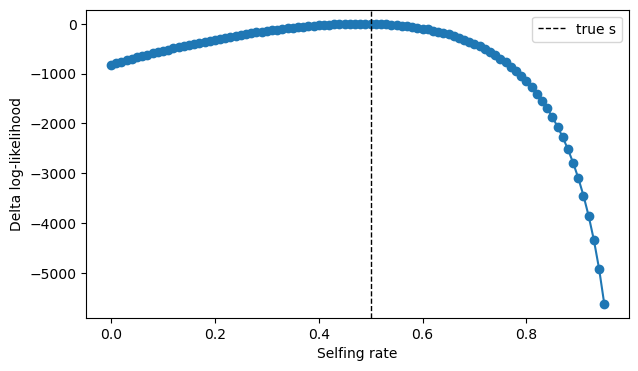

In [4]:
result = run_validation_experiment(config)[0]
summary = pd.Series({
    'generating s': result.true_s,
    'estimated s': result.fit.best_s,
    'support interval': f'{result.fit.support_interval[0]:.2f}–{result.fit.support_interval[1]:.2f}',
    'segregating sites': result.fit.n_sites,
    'independent loci': len(result.loci),
})
display(summary)
plot_likelihood_curve(result.fit, true_s=config.true_s);

The dashed line marks the generating selfing rate. The likelihood peak is close by. As always, remember that the support interval is a composite-likelihood summary and does not account for linkage within loci.

## Extending from one experiment to a validation study

This notebook ran one replicate at one generating selfing rate. A validation study repeats the same workflow across the settings to study the effect of those setting. For example, several generating selfing rates, population sizes, sample sizes, or locus counts. Set `n_reps` above 1 to generate independent pooled datasets under each configuration, and give each configuration its own output directory. The command-line equivalent is `selfdgs simulate`, which uses the same `ValidationExperimentConfig` and `run_validation_experiment` workflow.

Each saved experiment contains `validation_config.json` and `validation_summary.csv`. Its `repNNN` directories contain the fitted result, likelihood and DGS tables, per-locus seeds and SLiM commands in `loci.csv`, and captured SLiM logs. Keeping these directories makes the simulation settings and every fitted replicate auditable.

For a study stored in directories such as `validation/ne100_self0.2` and `validation/ne100_self0.5`, consolidate the completed experiments with:

```python
from selfdgs.validation import (
    discover_validation_runs,
    load_validation_collection,
    summarize_estimator_recovery,
)

runs = discover_validation_runs("validation")
estimates = load_validation_collection(runs)
recovery = summarize_estimator_recovery(estimates)
```

`recovery` reports the number of fitted replicates, mean and median estimates, bias, mean absolute error, and RMSE for each available `(ne, true_s)` setting. `load_likelihood_collection` can similarly combine the saved likelihood curves when curve-level diagnostics are needed. A useful study should choose its parameter grid and replication level from the intended biological application. This recipe is mostly meant to demonstrate the mechanics rather than prescribing a universally adequate design.